In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
house=pd.read_csv(r"C:\Users\Student\Desktop\house.csv")
house.sample(3)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
3245,72,2,False,False,False,Pirouzi,2.376000e+09,79200.00
1516,88,2,False,False,True,Parand,4.850000e+08,16166.67
3143,98,2,True,True,True,Shahran,4.080000e+09,136000.00


In [3]:
house.dtypes

Area           object
Room            int64
Parking          bool
Warehouse        bool
Elevator         bool
Address        object
Price         float64
Price(USD)    float64
dtype: object

In [4]:
house.columns

Index(['Area', 'Room', 'Parking', 'Warehouse', 'Elevator', 'Address', 'Price',
       'Price(USD)'],
      dtype='object')

In [5]:
house["Area"]=pd.to_numeric(house["Area"],errors="coerce")
house[['Parking', 'Warehouse', 'Elevator']]=house[['Parking', 'Warehouse', 'Elevator']].astype(int)

In [6]:
house.dtypes

Area          float64
Room            int64
Parking         int32
Warehouse       int32
Elevator        int32
Address        object
Price         float64
Price(USD)    float64
dtype: object

In [7]:
house.isnull().sum()

Area           6
Room           0
Parking        0
Warehouse      0
Elevator       0
Address       23
Price          0
Price(USD)     0
dtype: int64

In [8]:
house.shape

(3479, 8)

In [9]:
# house.dropna("Area", "Address", inplace=True)

In [10]:
house.dropna(subset=["Area", "Address"], inplace=True)

In [11]:
house.drop_duplicates(inplace=True)

In [12]:
house.reset_index(drop=True,inplace=True)

In [13]:
house["Address code"]=house["Address"].astype("category").cat.codes

In [14]:
house.Address.value_counts

<bound method IndexOpsMixin.value_counts of 0                  Shahran
1                  Shahran
2                   Pardis
3            Shahrake Qods
4           Shahrake Gharb
               ...        
3237           Feiz Garden
3238    Southern Janatabad
3239              Niavaran
3240                Dorous
3241                Parand
Name: Address, Length: 3242, dtype: object>

In [15]:
house.sample(5)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Address code
665,85.0,2,1,1,1,Pardis,6.000000e+08,20000.00,117
1446,90.0,2,1,1,1,Shahr-e-Ziba,3.150000e+09,105000.00,146
1621,380.0,4,1,1,1,Elahieh,5.000000e+10,1666666.67,44
540,105.0,2,1,1,1,Southern Janatabad,5.300000e+09,176666.67,163
2149,68.0,2,1,1,0,West Ferdows Boulevard,2.300000e+09,76666.67,183


In [16]:
average=house.groupby("Address")["Price"].mean()
average
# average=average.reset_index()
# # average.describe()

# sb.barplot(x="Address", y="Price", data=average.sample(3))
# # plt.xticks(np.arange(0,3,1),rotation=-90)
# # plt.yticks(np.arange(0,3,1))
# plt.show()

Address
Abazar         8.594130e+09
Abbasabad      3.230000e+09
Absard         4.233333e+09
Abuzar         1.528333e+09
Afsarieh       1.866667e+09
                   ...     
Yousef Abad    7.031974e+09
Zafar          1.317440e+10
Zaferanieh     2.357515e+10
Zargandeh      7.068000e+09
Zibadasht      4.350000e+09
Name: Price, Length: 192, dtype: float64

In [17]:
price_per_area=(house.groupby("Address").apply(lambda x:x["Price"].sum()/x["Area"].sum()))
house["avg_price_area"]=house["Address"].map(price_per_area)

In [18]:
house.sample(5)

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Address code,avg_price_area
2006,63.0,2,0,1,0,Qasr-od-Dasht,1.260000e+09,42000.00,125,2.323726e+07
2258,80.0,2,1,1,1,Punak,3.000000e+09,100000.00,122,4.415976e+07
2087,172.0,3,1,1,1,Heravi,9.300000e+09,310000.00,68,5.711503e+07
608,100.0,3,1,1,1,Pardis,5.000000e+08,16666.67,117,8.204639e+06
3222,86.0,2,0,1,0,Vahidiyeh,5.200000e+08,17333.33,175,6.517647e+06


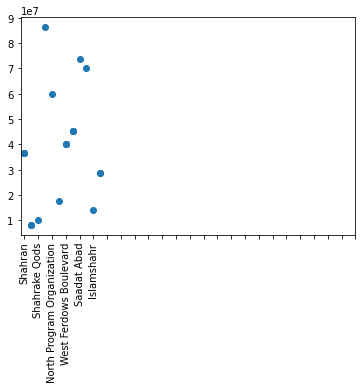

In [19]:
plt.scatter(house["Address"][0:20],house["avg_price_area"][0:20])
plt.xticks(np.arange(0,50,2),rotation=90)
plt.show()

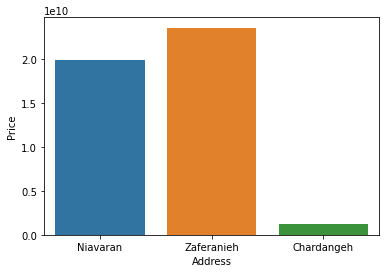

In [20]:
# average=house.groupby("Address")["avg_price_area"]
price_per_area=(house.groupby("Address").apply(lambda x:x["Price"].sum()/x["Area"].sum()))

# average
average=average.reset_index()
# # average.describe()

sb.barplot(x="Address", y="Price", data=average.sample(3))
# # plt.xticks(np.arange(0,3,1),rotation=-90)
# # plt.yticks(np.arange(0,3,1))
plt.show()

In [21]:
house["new"]=house["Price"]/house["Area"]
house.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Address code,avg_price_area,new
0,63.0,1,1,1,1,Shahran,1.850000e+09,61666.67,156,3.668519e+07,2.936508e+07
1,60.0,1,1,1,1,Shahran,1.850000e+09,61666.67,156,3.668519e+07,3.083333e+07
2,79.0,2,1,1,1,Pardis,5.500000e+08,18333.33,117,8.204639e+06,6.962025e+06
3,95.0,2,1,1,1,Shahrake Qods,9.025000e+08,30083.33,152,1.000572e+07,9.500000e+06
4,123.0,2,1,1,1,Shahrake Gharb,7.000000e+09,233333.33,150,8.625069e+07,5.691057e+07
